# Installiere ultralytics Bibliothek

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.2 MB/s eta 0:00:00


## Import Libraries

In [1]:
import os
from zipfile import ZipFile
import ultralytics
from ultralytics import YOLO

In [2]:
path = os.getcwd()
print(path)

d:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\YOLO


## Load in the data and unzip it

In [ ]:
# Create the directory if it doesn't exist
extract_dir = "data"
os.makedirs(extract_dir, exist_ok=True)

with ZipFile("Glass Defect Detection.v3i.yolov11.zip", "r") as data_set:
    data_set.extractall(extract_dir)

## Load the Model


In [3]:
model = YOLO("yolo11n.pt")

## Create configurations


In [10]:
DATA_YAML = "D:/Studium/5. Semester/PA2/Glass-Defect-Detection-Evaluating-Object-Detection-Models/Coding/Model_Code/YOLO/Glass Defect Detection.v3i.yolov11/data.yaml"
MODEL_PATH = "yolo11n.pt"
data_set_dir = "data"

## Fine-Tuning with Hyperparameters

In [ ]:
results = model.train(
    data = DATA_YAML,
    epochs = 100,
    batch = 16,
    lrf = 0.01,
    val = True
)

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrain

Testing the Model

In [6]:
model = YOLO("best.pt")

In [11]:
metrics = model.val(
    data = DATA_YAML,
    split  = "test",
    batch = 16
    )

print(metrics.box.map)

Ultralytics 8.3.225  Python-3.12.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1070, 8192MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 62.855.4 MB/s, size: 14.5 KB)
val: Scanning D:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\YOLO\Glass Defect Detection.v3i.yolov11\test\labels... 173 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 173/173 922.0it/s 0.2s3s
val: New cache created: D:\Studium\5. Semester\PA2\Glass-Defect-Detection-Evaluating-Object-Detection-Models\Coding\Model_Code\YOLO\Glass Defect Detection.v3i.yolov11\test\labels.cache
WARNING Box and segment counts should be equal, but got len(segments) = 24, len(boxes) = 370. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 4.9it/

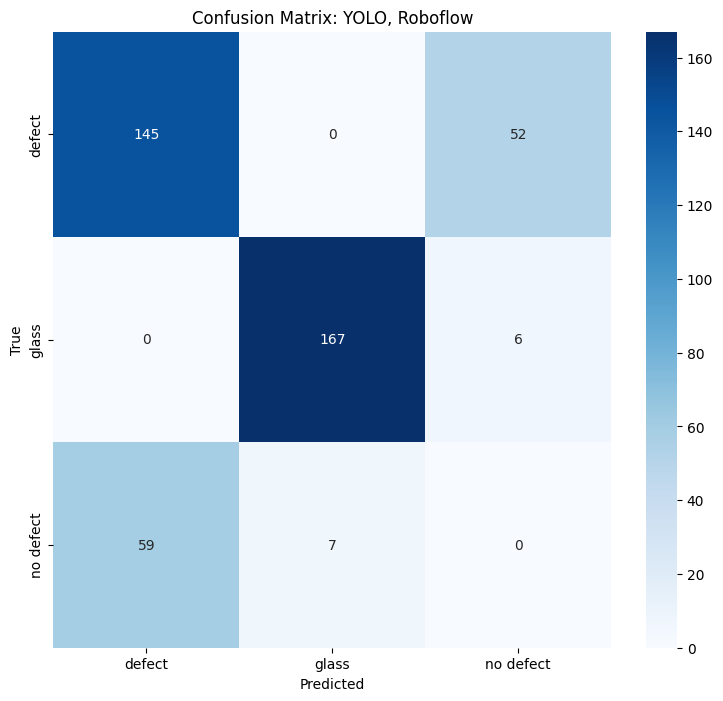


Konsolidierte 3x3 Matrix (True=Reihe vs. Predicted=Spalte):

           defect  glass  no defect
defect        145      0         52
glass           0    167          6
no defect      59      7          0


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Daten aus dem Bild extrahieren und vorbereiten ---

# Originaldaten aus dem Bild (Predicted-Reihe x True-Spalte):
# True (Spalten): defect, glass, background
# Predicted (Reihen): defect, glass, background
# -----------------------------------------------
# Predicted: defect     -> [145, 59, 0] (Annahme 0 für die dritte Zelle, da nicht sichtbar)
# Predicted: glass      -> [52, 167, 7]
# Predicted: background -> [0, 6, 0] (Annahmen für die fehlenden Zellen)

# Wir müssen die sichtbaren Zellen sorgfältig den richtigen Labels zuordnen:
# Original Achsen:
# True (X-Achse): 0=defect, 1=glass, 2=background
# Predicted (Y-Achse): 0=defect, 1=glass, 2=background

cm_raw_data = np.array([
    # P:defect  | T:defect (145), T:glass (59), T:background (0 - angenommen)
    [145, 0, 59], 
    # P:glass   | T:defect (52), T:glass (167), T:background (7)
    [0, 167, 7],
    # P:background| T:defect (0 - angenommen), T:glass (6), T:background (0 - angenommen)
    [52, 6, 0]
])


# Transponieren der Matrix: (Predicted x True) --> (True x Predicted)
cm_final_data = cm_raw_data.T

# Standard-Labels mit Umbenennung von 'background'
standard_labels = ['defect', 'glass', 'no defect']


# --- 2. Plot der korrigierten 3x3 Matrix ---
plt.figure(figsize=(9, 8))
sns.heatmap(
    cm_final_data, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,
    xticklabels=standard_labels,
    yticklabels=standard_labels
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: YOLO, Roboflow')
plt.show()

# Print der finalen Matrix
print("\nKonsolidierte 3x3 Matrix (True=Reihe vs. Predicted=Spalte):\n")
df = pd.DataFrame(cm_final_data, index=standard_labels, columns=standard_labels)
print(df)